### Downloading data from kaggle


In [18]:
!pip install opendatasets legacy-cgi --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/fahadullaha/facial-emotion-recognition-dataset")

Skipping, found downloaded files in "./facial-emotion-recognition-dataset" (use force=True to force download)


### Importing libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
from PIL import Image # used to read the images from the directory
import torch
from torch import nn
from torch.optim import Adam
import torchvision.transforms as transforms # used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### loading data to dataframe

In [21]:
image_path = []
labels = []

for label in os.listdir("facial-emotion-recognition-dataset/processed_data/"):
  label_path = os.path.join("facial-emotion-recognition-dataset/processed_data/", label)
  if os.path.isdir(label_path):
    for image in os.listdir(label_path):
      labels.append(label)
      image_path.append(os.path.join(label_path, image))

df = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels'])
df.head()

,image_paths,labels
0,facial-emotion-recognition-dataset/processed_d...,happy
1,facial-emotion-recognition-dataset/processed_d...,happy
2,facial-emotion-recognition-dataset/processed_d...,happy
3,facial-emotion-recognition-dataset/processed_d...,happy
4,facial-emotion-recognition-dataset/processed_d...,happy


In [22]:
df['labels'].value_counts()

,count
labels,
happy,11398
neutral,8166
sad,6535
angry,5920
fear,5920
surprise,5920
disgust,5920


### Splitting data
- Training: 70% (of 100% data)
- Validation: 15% (50% of 30% data)
- Testing: 15% (50% of 30% data)

In [23]:
# create train_data of 70% of the data
train_data = df.sample(frac=0.7, random_state=7)

# drop training rows to get the remaining 30% for the remaining data
remaining = df.drop(train_data.index)

# split the remaining 30% in half (50%) to get Test and Validation
test_data = remaining.sample(frac=0.5, random_state=7)
validation_data = remaining.drop(test_data.index)

print(f"The original dataset has {len(df)} rows")
print(f"The training dataset has {len(train_data)} rows which is 70% of the data")
print(f"The validation dataset has {len(validation_data)} rows which is 15% of the data")
print(f"The testing dataset has {len(test_data)} rows which is 15% of the data")

The original dataset has 49779 rows
The training dataset has 34845 rows which is 70% of the data
The validation dataset has 7467 rows which is 15% of the data
The testing dataset has 7467 rows which is 15% of the data


### Label encoding

In [24]:
label_encoder = LabelEncoder()
label_encoder.fit(df['labels'])

LabelEncoder()

### Image preprocessing

In [25]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)), # one size for all images
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

### Custom Dataset Class

In [26]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels']))

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

### Creating Dataset Objects

In [27]:
train_dataset = CustomImageDataset(dataframe=train_data, transform=train_transform)
test_dataset = CustomImageDataset(dataframe=test_data, transform=transform)
validation_dataset = CustomImageDataset(dataframe=validation_data, transform=transform)

### Visualizing images

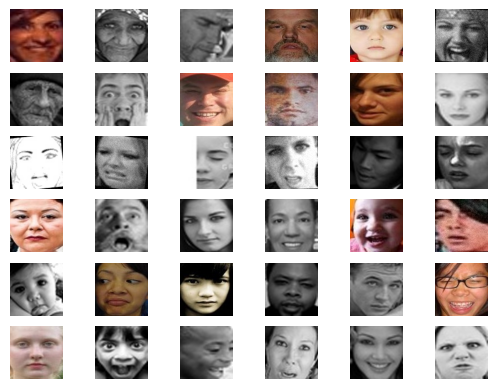

In [28]:
n_rows = 6
n_cols = 6
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [29]:
learning_rate = 1e-4
batch_size = 32
epochs = 50


In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

### Model Training

In [31]:

class EmotionDetectionModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, len(df["labels"].unique()))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = EmotionDetectionModel().to(device)

### Model Creation

In [32]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

In [33]:
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

### Training Loop

In [34]:
total_training_loss = []
total_validation_loss = []
total_training_accuracy = []
total_validation_accuracy = []

for epoch in range(epochs):

    total_train_loss = 0
    total_train_accuracy = 0
    total_val_loss = 0
    total_val_accuracy = 0

    # training
    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        prediction = model(images)
        loss = criterion(prediction, labels)

        total_train_loss += loss.item()

        accuracy = (torch.argmax(prediction, dim=1) == labels).sum().item()
        total_train_accuracy += accuracy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # validation
    model.eval()

    with torch.no_grad():

        for images, labels in validation_loader:

            images = images.to(device)
            labels = labels.to(device)

            prediction = model(images)
            loss = criterion(prediction, labels)

            total_val_loss += loss.item()

            accuracy = (torch.argmax(prediction, dim=1) == labels).sum().item()
            total_val_accuracy += accuracy

    # average metrics
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(validation_loader)

    train_accuracy = total_train_accuracy / len(train_dataset) * 100
    val_accuracy = total_val_accuracy / len(validation_dataset) * 100

    # store metrics
    total_training_loss.append(train_loss)
    total_validation_loss.append(val_loss)
    total_training_accuracy.append(train_accuracy)
    total_validation_accuracy.append(val_accuracy)

    print(f"| Epoch: {epoch + 1} | Train Accuracy: {train_accuracy:.2f}% | Train Loss: {train_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}% | Validation Loss: {val_loss:.4f} |")
    print("-" * 114)

| Epoch: 1 | Train Accuracy: 34.16% | Train Loss: 1.6782 | Validation Accuracy: 47.60% | Validation Loss: 1.4322 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 2 | Train Accuracy: 45.81% | Train Loss: 1.4310 | Validation Accuracy: 51.88% | Validation Loss: 1.3069 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 3 | Train Accuracy: 49.02% | Train Loss: 1.3378 | Validation Accuracy: 53.90% | Validation Loss: 1.2394 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 4 | Train Accuracy: 51.62% | Train Loss: 1.2723 | Validation Accuracy: 55.79% | Validation Loss: 1.1757 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 5 | Train Accuracy: 53.33% | Train Loss: 1.2235 | Validation Accuracy: 

### Model Testing

In [50]:
model.eval()

total_test_loss = 0
total_test_accuracy = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        prediction = model(images)

        loss = criterion(prediction, labels)
        total_test_loss += loss.item()

        predicted = torch.argmax(prediction, dim=1)
        correct = (predicted == labels).sum().item()
        total_test_accuracy += correct

test_loss = total_test_loss / len(test_loader)
test_accuracy = total_test_accuracy / len(test_loader.dataset) * 100

print("-" * 45)
print(f"| Test Accuracy: {test_accuracy:.2f}% | Test Loss: {test_loss:.4f} |")
print("-" * 45)

---------------------------------------------
| Test Accuracy: 68.23% | Test Loss: 1.0164 |
---------------------------------------------


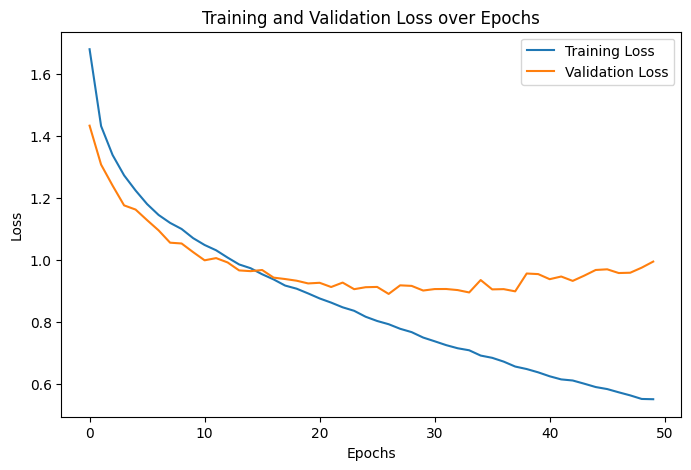

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(total_training_loss, label='Training Loss')
plt.plot(total_validation_loss, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

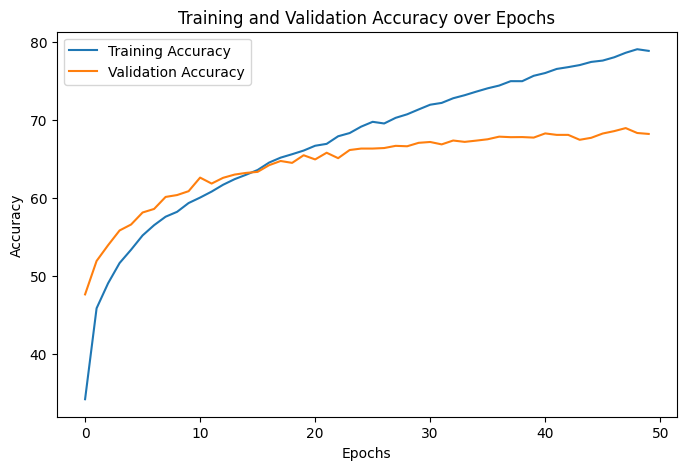

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(total_training_accuracy, label='Training Accuracy')
plt.plot(total_validation_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Model Testing**

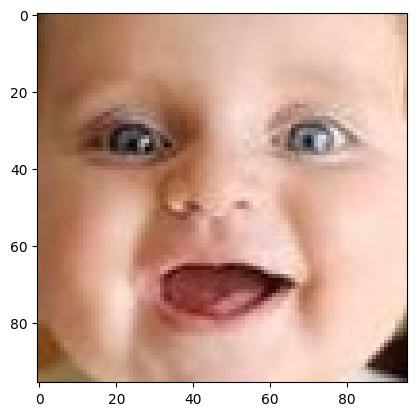


Prediction: 

['happy']


In [53]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output])

## Get a sample image from the dataset
sample_image_path = df.sample(n=1)['image_paths'].iloc[0]

## Visualize the image
image = Image.open(sample_image_path)
plt.imshow(image)
plt.show()


## Predict
print()
print("Prediction: \n")
prediction = predict_image(sample_image_path)
print(prediction)

In [54]:
# saves the model for deployment
torch.save(model.state_dict(), 'emotion_classifier.pth')
print("Model successfully saved to emotion_classifier.pth")

Model successfully saved to emotion_classifier.pth
